In [ ]:
{
  "PC1": {
    "Router": 2,
    "MailServer": 4
  },
  "Router": {
    "Firewall": 3,
    "WebServer": 5
  },
  "Firewall": {
    "Database": 7
  },
  "WebServer": {
    "Database": 2
  },
  "MailServer": {
    "BackupServer": 6
  },
  "BackupServer": {
    "Database": 3
  },
  "Database": {}
}

{'PC1': {'Router': 2, 'MailServer': 4},
 'Router': {'Firewall': 3, 'WebServer': 5},
 'Firewall': {'Database': 7},
 'WebServer': {'Database': 2},
 'MailServer': {'BackupServer': 6},
 'BackupServer': {'Database': 3},
 'Database': {}}

In [ ]:
from collections import deque

def bfs(graph, start, goal):

    queue = deque([(start, [start])])
    visited = set()

    while queue:

        node, path = queue.popleft()

        if node == goal:
            return path

        if node not in visited:

            visited.add(node)

            for neighbor in graph[node]:

                queue.append(
                    (neighbor, path + [neighbor])
                )

    return None

In [ ]:
def dfs(graph, start, goal, path=None):

    if path is None:
        path = []

    path = path + [start]

    if start == goal:
        return path

    for neighbor in graph[start]:

        if neighbor not in path:

            result = dfs(
                graph,
                neighbor,
                goal,
                path
            )

            if result:
                return result

    return None

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

G = nx.Graph()

for node in graph:

    for neighbor, weight in graph[node].items():

        G.add_edge(node, neighbor, weight=weight)

pos = nx.spring_layout(G)

nx.draw(
    G,
    pos,
    with_labels=True,
    node_size=3000
)

labels = nx.get_edge_attributes(G, 'weight')

nx.draw_networkx_edge_labels(
    G,
    pos,
    edge_labels=labels
)

plt.show()

NameError: name 'graph' is not defined

In [ ]:
graph = {
    "PC1": {
        "Router": 2,
        "MailServer": 4
    },

    "Router": {
        "Firewall": 3,
        "WebServer": 5
    },

    "MailServer": {
        "BackupServer": 6
    },

    "Firewall": {
        "Database": 7
    },

    "WebServer": {
        "Database": 2
    },

    "BackupServer": {
        "Database": 3
    },

    "Database": {}
}

In [ ]:
from collections import deque
import time

def bfs(graph, start, goal):

    start_time = time.time()

    queue = deque([(start, [start], 0)])

    visited = set()

    nodes_expanded = 0

    while queue:

        current, path, cost = queue.popleft()

        nodes_expanded += 1

        if current == goal:

            execution_time = (time.time() - start_time) * 1000

            return {
                "Path": path,
                "Cost": cost,
                "Nodes Expanded": nodes_expanded,
                "Time(ms)": execution_time
            }

        if current not in visited:

            visited.add(current)

            for neighbor, edge_cost in graph[current].items():

                queue.append(
                    (
                        neighbor,
                        path + [neighbor],
                        cost + edge_cost
                    )
                )

    return None

In [ ]:
import time

def dfs(graph, start, goal):

    start_time = time.time()

    stack = [(start, [start], 0)]

    visited = set()

    nodes_expanded = 0

    while stack:

        current, path, cost = stack.pop()

        nodes_expanded += 1

        if current == goal:

            execution_time = (time.time() - start_time) * 1000

            return {
                "Path": path,
                "Cost": cost,
                "Nodes Expanded": nodes_expanded,
                "Time(ms)": execution_time
            }

        if current not in visited:

            visited.add(current)

            for neighbor, edge_cost in graph[current].items():

                stack.append(
                    (
                        neighbor,
                        path + [neighbor],
                        cost + edge_cost
                    )
                )

    return None

In [ ]:
import heapq
import time

def ucs(graph, start, goal):

    start_time = time.time()

    priority_queue = [(0, start, [start])]

    visited = set()

    nodes_expanded = 0

    while priority_queue:

        cost, current, path = heapq.heappop(priority_queue)

        nodes_expanded += 1

        if current == goal:

            execution_time = (time.time() - start_time) * 1000

            return {
                "Path": path,
                "Cost": cost,
                "Nodes Expanded": nodes_expanded,
                "Time(ms)": execution_time
            }

        if current not in visited:

            visited.add(current)

            for neighbor, edge_cost in graph[current].items():

                heapq.heappush(
                    priority_queue,
                    (
                        cost + edge_cost,
                        neighbor,
                        path + [neighbor]
                    )
                )

    return None

In [ ]:
heuristic = {
    "PC1": 10,
    "Router": 8,
    "MailServer": 7,
    "Firewall": 5,
    "WebServer": 2,
    "BackupServer": 3,
    "Database": 0
}

In [ ]:
import heapq
import time

def astar(graph, start, goal, heuristic):

    start_time = time.time()

    priority_queue = [(0, 0, start, [start])]

    visited = set()

    nodes_expanded = 0

    while priority_queue:

        f_cost, g_cost, current, path = heapq.heappop(priority_queue)

        nodes_expanded += 1

        if current == goal:

            execution_time = (time.time() - start_time) * 1000

            return {
                "Path": path,
                "Cost": g_cost,
                "Nodes Expanded": nodes_expanded,
                "Time(ms)": execution_time
            }

        if current not in visited:

            visited.add(current)

            for neighbor, edge_cost in graph[current].items():

                new_g = g_cost + edge_cost

                new_f = new_g + heuristic[neighbor]

                heapq.heappush(
                    priority_queue,
                    (
                        new_f,
                        new_g,
                        neighbor,
                        path + [neighbor]
                    )
                )

    return None

In [ ]:
import time

def hill_climbing(graph, start, goal, heuristic):

    start_time = time.time()

    current = start

    path = [current]

    total_cost = 0

    nodes_expanded = 0

    while current != goal:

        nodes_expanded += 1

        neighbors = graph[current]

        if not neighbors:

            break

        next_node = min(
            neighbors,
            key=lambda x: heuristic[x]
        )

        if heuristic[next_node] >= heuristic[current]:

            execution_time = (time.time() - start_time) * 1000

            return {
                "Path": path,
                "Cost": total_cost,
                "Nodes Expanded": nodes_expanded,
                "Time(ms)": execution_time,
                "Status": "Failed - Local Maximum"
            }

        total_cost += graph[current][next_node]

        current = next_node

        path.append(current)

    execution_time = (time.time() - start_time) * 1000

    return {
        "Path": path,
        "Cost": total_cost,
        "Nodes Expanded": nodes_expanded,
        "Time(ms)": execution_time,
        "Status": "Success"
    }

In [ ]:
import math

tree = {
    'A': ['B', 'C'],
    'B': ['D', 'E'],
    'C': ['F', 'G']
}

scores = {
    'D': 3,
    'E': 5,
    'F': 2,
    'G': 9
}

def minimax(node, depth, maximizing_player):

    if depth == 0 or node not in tree:
        return scores[node]

    if maximizing_player:

        best_value = -math.inf

        for child in tree[node]:

            value = minimax(
                child,
                depth - 1,
                False
            )

            best_value = max(best_value, value)

        return best_value

    else:

        best_value = math.inf

        for child in tree[node]:

            value = minimax(
                child,
                depth - 1,
                True
            )

            best_value = min(best_value, value)

        return best_value

In [ ]:
import math

def alpha_beta(node, depth, alpha, beta, maximizing_player):

    if depth == 0 or node not in tree:
        return scores[node]

    if maximizing_player:

        value = -math.inf

        for child in tree[node]:

            value = max(
                value,
                alpha_beta(
                    child,
                    depth - 1,
                    alpha,
                    beta,
                    False
                )
            )

            alpha = max(alpha, value)

            if beta <= alpha:
                break

        return value

    else:

        value = math.inf

        for child in tree[node]:

            value = min(
                value,
                alpha_beta(
                    child,
                    depth - 1,
                    alpha,
                    beta,
                    True
                )
            )

            beta = min(beta, value)

            if beta <= alpha:
                break

        return value

In [ ]:
start_node = "PC1"
goal_node = "Database"

print("\nBFS Result")
print(bfs(graph, start_node, goal_node))

print("\nDFS Result")
print(dfs(graph, start_node, goal_node))

print("\nUCS Result")
print(ucs(graph, start_node, goal_node))

print("\nA* Result")
print(astar(graph, start_node, goal_node, heuristic))

print("\nHill Climbing Result")
print(
    hill_climbing(
        graph,
        start_node,
        goal_node,
        heuristic
    )
)

print("\nMinimax Result")
print(minimax('A', 2, True))

print("\nAlpha-Beta Result")
print(
    alpha_beta(
        'A',
        2,
        -math.inf,
        math.inf,
        True
    )
)


BFS Result
{'Path': ['PC1', 'Router', 'Firewall', 'Database'], 'Cost': 12, 'Nodes Expanded': 7, 'Time(ms)': 0.024318695068359375}

DFS Result
{'Path': ['PC1', 'MailServer', 'BackupServer', 'Database'], 'Cost': 13, 'Nodes Expanded': 4, 'Time(ms)': 0.010728836059570312}

UCS Result
{'Path': ['PC1', 'Router', 'WebServer', 'Database'], 'Cost': 9, 'Nodes Expanded': 6, 'Time(ms)': 0.01811981201171875}

A* Result
{'Path': ['PC1', 'Router', 'WebServer', 'Database'], 'Cost': 9, 'Nodes Expanded': 4, 'Time(ms)': 0.011920928955078125}

Hill Climbing Result
{'Path': ['PC1', 'MailServer', 'BackupServer', 'Database'], 'Cost': 13, 'Nodes Expanded': 3, 'Time(ms)': 0.012636184692382812, 'Status': 'Success'}

Minimax Result
3

Alpha-Beta Result
3


In [ ]:
results = []

results.append(("BFS", bfs(graph, start_node, goal_node)))
results.append(("DFS", dfs(graph, start_node, goal_node)))
results.append(("UCS", ucs(graph, start_node, goal_node)))
results.append(("A*", astar(graph, start_node, goal_node, heuristic)))
results.append(("Hill Climbing",
                hill_climbing(graph,
                              start_node,
                              goal_node,
                              heuristic)))

print("\nComparison Table\n")

print("{:<20} {:<15} {:<20} {:<20}".format(
    "Algorithm",
    "Cost",
    "Nodes Expanded",
    "Time(ms)"
))

for name, result in results:

    print("{:<20} {:<15} {:<20} {:<20}".format(
        name,
        result["Cost"],
        result["Nodes Expanded"],
        round(result["Time(ms)"], 4)
    ))


Comparison Table

Algorithm            Cost            Nodes Expanded       Time(ms)            
BFS                  12              7                    0.0167              
DFS                  13              4                    0.0052              
UCS                  9               6                    0.0126              
A*                   9               4                    0.0067              
Hill Climbing        13              3                    0.0093              


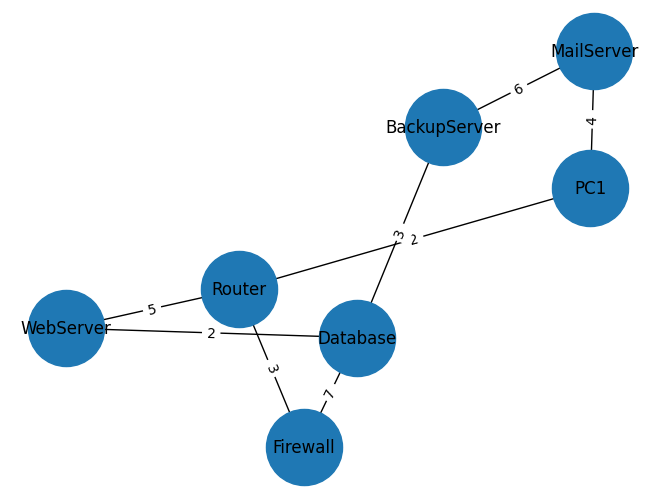

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

G = nx.Graph()

for node in graph:

    for neighbor, weight in graph[node].items():

        G.add_edge(node, neighbor, weight=weight)

pos = nx.spring_layout(G)

nx.draw(
    G,
    pos,
    with_labels=True,
    node_size=3000
)

labels = nx.get_edge_attributes(G, 'weight')

nx.draw_networkx_edge_labels(
    G,
    pos,
    edge_labels=labels
)

plt.show()